# 03 Modeling

This notebook trains and evaluates a proof-of-concept Ridge Regression model for job-level mean double-shear strength. A mean baseline model is included for comparison, and validation is grouped by material lot to avoid splitting related lot-level records across train and test sets.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make paths work whether the notebook is run from the repo root or notebooks folder
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR

DATA_DIR = REPO_ROOT / "data"
FIGURE_DIR = REPO_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

processed_path = DATA_DIR / "processed_material_database.csv"

from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor


## Load processed dataset and feature list

In [2]:
df = pd.read_csv(processed_path)
feature_info = pd.read_csv(DATA_DIR / "feature_list.csv")

numeric_features = feature_info.loc[feature_info["type"] == "numeric", "feature"].tolist()
categorical_features = feature_info.loc[feature_info["type"] == "categorical", "feature"].tolist()

target_col = "MeanShear_ksi"
group_col = "Lot_ID"

print("Dataset shape:")
print(df.shape)

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Dataset shape:
(6, 42)

Numeric features:
['AgeTemp_F', 'AgeTime_hr', 'HeatTreatSequence', 'Reaged', 'Mean_OD_in', 'Mean_ID_in', 'MeanNetArea_in2', 'Mean_HRC', 'SpecimenCount', 'C', 'Mn', 'Si', 'P', 'S', 'Ni', 'Cr', 'Mo', 'Cu', 'RawDiameter', 'SolutionTemp_F', 'SolutionTime_hr', 'CertAgeTemp_F', 'CertAgeTime_hr', 'SolutionHard_HBW', 'Cert_UTS_ksi', 'Cert_Yield_ksi', 'Cert_Elong_pct', 'Cert_RA_pct']

Categorical features:
['TestStage']


## Prepare model data

Numerical missing values are filled with the median of the available data. This keeps the proof-of-concept workflow running while avoiding loss of all rows from columns that are partially missing.

In [3]:
model_cols = numeric_features + categorical_features + [target_col, group_col]
model_df = df[model_cols].copy()

# Fill missing values in a simple, transparent way
for col in numeric_features:
    model_df[col] = model_df[col].fillna(model_df[col].median())

for col in categorical_features:
    model_df[col] = model_df[col].fillna("Unknown")

model_df = model_df.dropna(subset=[target_col, group_col]).reset_index(drop=True)

X = model_df[numeric_features + categorical_features]
y = model_df[target_col]
groups = model_df[group_col]

print("Model dataframe shape:")
print(model_df.shape)

print("\nUnique lots:")
print(groups.nunique())

display(model_df.head())


Model dataframe shape:
(6, 31)

Unique lots:
2


,AgeTemp_F,AgeTime_hr,HeatTreatSequence,Reaged,Mean_OD_in,Mean_ID_in,MeanNetArea_in2,Mean_HRC,SpecimenCount,C,...,CertAgeTemp_F,CertAgeTime_hr,SolutionHard_HBW,Cert_UTS_ksi,Cert_Yield_ksi,Cert_Elong_pct,Cert_RA_pct,TestStage,MeanShear_ksi,Lot_ID
0,1160,4,1,0,1.349767,0.730267,1.012049,29.750000,6,0.04,...,900.0,1.0,319.0,199.0,180.0,16.0,56.0,T1,91.038919,16347
1,1180,4,2,1,1.349583,0.730233,1.011698,25.733333,6,0.04,...,900.0,1.0,319.0,199.0,180.0,16.0,56.0,T1A,87.471372,16347
2,1180,4,2,1,1.349654,0.737531,1.003436,25.653846,13,0.04,...,900.0,1.0,319.0,199.0,180.0,16.0,56.0,T2,88.097680,16347
3,1160,4,1,0,1.349750,0.730050,1.012262,30.250000,6,0.03,...,900.0,1.0,353.0,195.0,194.0,17.0,61.0,T1,91.675099,16827
4,1180,4,2,1,1.349650,0.721283,1.022043,25.583333,6,0.03,...,900.0,1.0,353.0,195.0,194.0,17.0,61.0,T1A,87.441029,16827


## Define baseline and Ridge Regression models

In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

baseline_model = DummyRegressor(strategy="mean")

ridge_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)


## Group-aware cross-validation

The validation split uses `Lot_ID` as the group key. This prevents the same material lot from appearing in both the training and test set within a fold.

In [5]:
unique_lots = groups.nunique()

if unique_lots < 2:
    raise ValueError("At least two unique lots are required for LeaveOneGroupOut validation.")

cv = LeaveOneGroupOut()

y_pred_baseline = cross_val_predict(
    baseline_model,
    X,
    y,
    cv=cv,
    groups=groups
)

y_pred_ridge = cross_val_predict(
    ridge_model,
    X,
    y,
    cv=cv,
    groups=groups
)

baseline_mae = mean_absolute_error(y, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y, y_pred_baseline))
baseline_r2 = r2_score(y, y_pred_baseline)

ridge_mae = mean_absolute_error(y, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y, y_pred_ridge))
ridge_r2 = r2_score(y, y_pred_ridge)

results = pd.DataFrame({
    "Model": ["Mean baseline", "Ridge Regression"],
    "MAE_ksi": [baseline_mae, ridge_mae],
    "RMSE_ksi": [baseline_rmse, ridge_rmse],
    "R2": [baseline_r2, ridge_r2]
})

display(results)
results.to_csv(DATA_DIR / "model_results.csv", index=False)
print("Saved model results to data/model_results.csv")


,Model,MAE_ksi,RMSE_ksi,R2
0,Mean baseline,1.677518,1.806403,-0.000752
1,Ridge Regression,0.561218,0.585207,0.894969


Saved model results to data/model_results.csv


## Save prediction table

In [6]:
prediction_table = model_df[[group_col, target_col]].copy()

if "TestStage" in model_df.columns:
    prediction_table["TestStage"] = model_df["TestStage"]

if "AgeTemp_F" in model_df.columns:
    prediction_table["AgeTemp_F"] = model_df["AgeTemp_F"]

prediction_table["Pred_Baseline_ksi"] = y_pred_baseline
prediction_table["Pred_Ridge_ksi"] = y_pred_ridge
prediction_table["Ridge_Error_ksi"] = prediction_table["Pred_Ridge_ksi"] - prediction_table[target_col]
prediction_table["Ridge_AbsError_ksi"] = prediction_table["Ridge_Error_ksi"].abs()

display(prediction_table)

prediction_table.to_csv(DATA_DIR / "model_predictions.csv", index=False)
print("Saved predictions to data/model_predictions.csv")


,Lot_ID,MeanShear_ksi,TestStage,AgeTemp_F,Pred_Baseline_ksi,Pred_Ridge_ksi,Ridge_Error_ksi,Ridge_AbsError_ksi
0,16347,91.038919,T1,1160,88.812141,91.549475,0.510556,0.510556
1,16347,87.471372,T1A,1180,88.812141,87.128830,-0.342542,0.342542
2,16347,88.097680,T2,1180,88.812141,87.478482,-0.619198,0.619198
3,16827,91.675099,T1,1160,88.869324,90.910850,-0.764248,0.764248
4,16827,87.441029,T1A,1180,88.869324,87.819323,0.378293,0.378293
5,16827,87.320294,T2,1180,88.869324,88.072764,0.752470,0.752470


Saved predictions to data/model_predictions.csv


## Prediction comparison plot

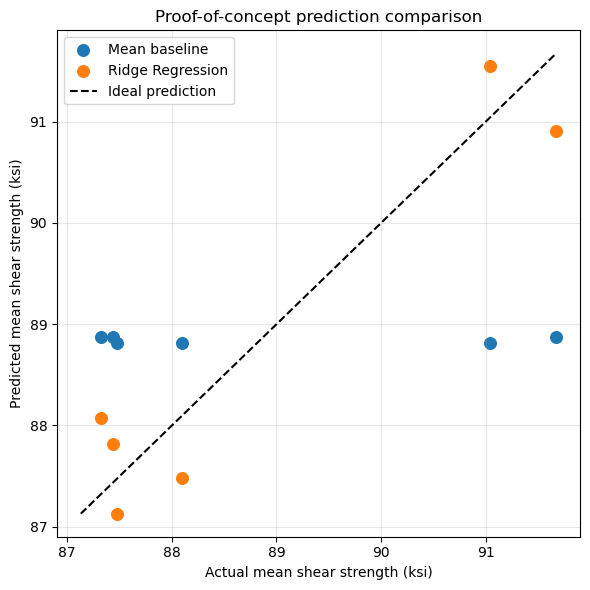

Saved figure to: /Users/SenkoBaby/Desktop/15-5ph-shear-strength-ml/figures/figure2_prediction_comparison.png


In [7]:
plt.figure(figsize=(6, 6))

plt.scatter(y, y_pred_baseline, label="Mean baseline", s=70)
plt.scatter(y, y_pred_ridge, label="Ridge Regression", s=70)

min_val = min(y.min(), y_pred_baseline.min(), y_pred_ridge.min())
max_val = max(y.max(), y_pred_baseline.max(), y_pred_ridge.max())

plt.plot([min_val, max_val], [min_val, max_val], "k--", label="Ideal prediction")

plt.xlabel("Actual mean shear strength (ksi)")
plt.ylabel("Predicted mean shear strength (ksi)")
plt.title("Proof-of-concept prediction comparison")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = FIGURE_DIR / "figure2_prediction_comparison.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {fig_path}")


## Fit final model for screening demonstration

The final model is fit on all available rows only for the proof-of-concept screening demonstration in Notebook 04. With the current dataset size, it should not be interpreted as a validated production model.

In [8]:
ridge_model.fit(X, y)
print("Final proof-of-concept Ridge model fit on all available data.")


Final proof-of-concept Ridge model fit on all available data.
